In [1]:
import tensorflow as tf
import os
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

MODEL_PATH = "../models/plantdoc_finetuned_best.keras"
CLASS_NAMES_PATH = "../evaluation_results/class_names.json"
PLANTDOC_TEST = "../../PlantDoc/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

if not os.path.exists(CLASS_NAMES_PATH):
    raise FileNotFoundError(f"Class names file not found: {CLASS_NAMES_PATH}")

if not os.path.exists(PLANTDOC_TEST):
    raise FileNotFoundError(f"PlantDoc test folder not found: {PLANTDOC_TEST}")

print("Loading PlantDoc model...")
model = tf.keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

print(f"Number of classes: {len(class_names)}")
print(f"Model output classes: {model.output_shape[-1]}")

test_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TEST,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_class_names = test_ds.class_names


test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\n" + "=" * 50)
print("PLANTDOC TEST RESULTS")
print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

I0000 00:00:1788090251.386118    6652 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788090252.180460    6652 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788090256.534521    6652 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading PlantDoc model...


I0000 00:00:1788090262.203418    6652 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Number of classes: 28
Model output classes: 28
Found 252 files belonging to 27 classes.


I0000 00:00:1788090274.272216    6791 cuda_dnn.cc:461] Loaded cuDNN version 92501


8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 188ms/step - accuracy: 0.4325 - loss: 2.6067

PLANTDOC TEST RESULTS
Test Loss     : 2.6067
Test Accuracy : 43.25%


In [36]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

report_path = os.path.join(
    OUTPUT_DIR,
    "plantdoc_classification_report.txt"
)

with open(report_path, "w") as f:
    f.write(report)

print("Classification report saved:", report_path)

                                precision    recall  f1-score   support

              Apple_cedar_rust     0.6000    0.6000    0.6000        10
                 Apple_healthy     0.3333    0.5556    0.4167         9
                    Apple_scab     0.5000    0.4000    0.4444        10
    Bell_pepper_bacterial_spot     0.3846    0.5556    0.4545         9
           Bell_pepper_healthy     0.4615    0.7500    0.5714         8
             Blueberry_healthy     0.5000    0.1818    0.2667        11
                Cherry_healthy     0.5000    0.4000    0.4444        10
              Corn_common_rust     0.6154    0.8000    0.6957        10
           Corn_gray_leaf_spot     0.5000    0.5000    0.5000         4
     Corn_northern_leaf_blight     0.7000    0.5833    0.6364        12
               Grape_black_rot     0.4286    0.3750    0.4000         8
                 Grape_healthy     0.7692    0.8333    0.8000        12
                 Peach_healthy     0.6667    0.4444    0.5333  

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


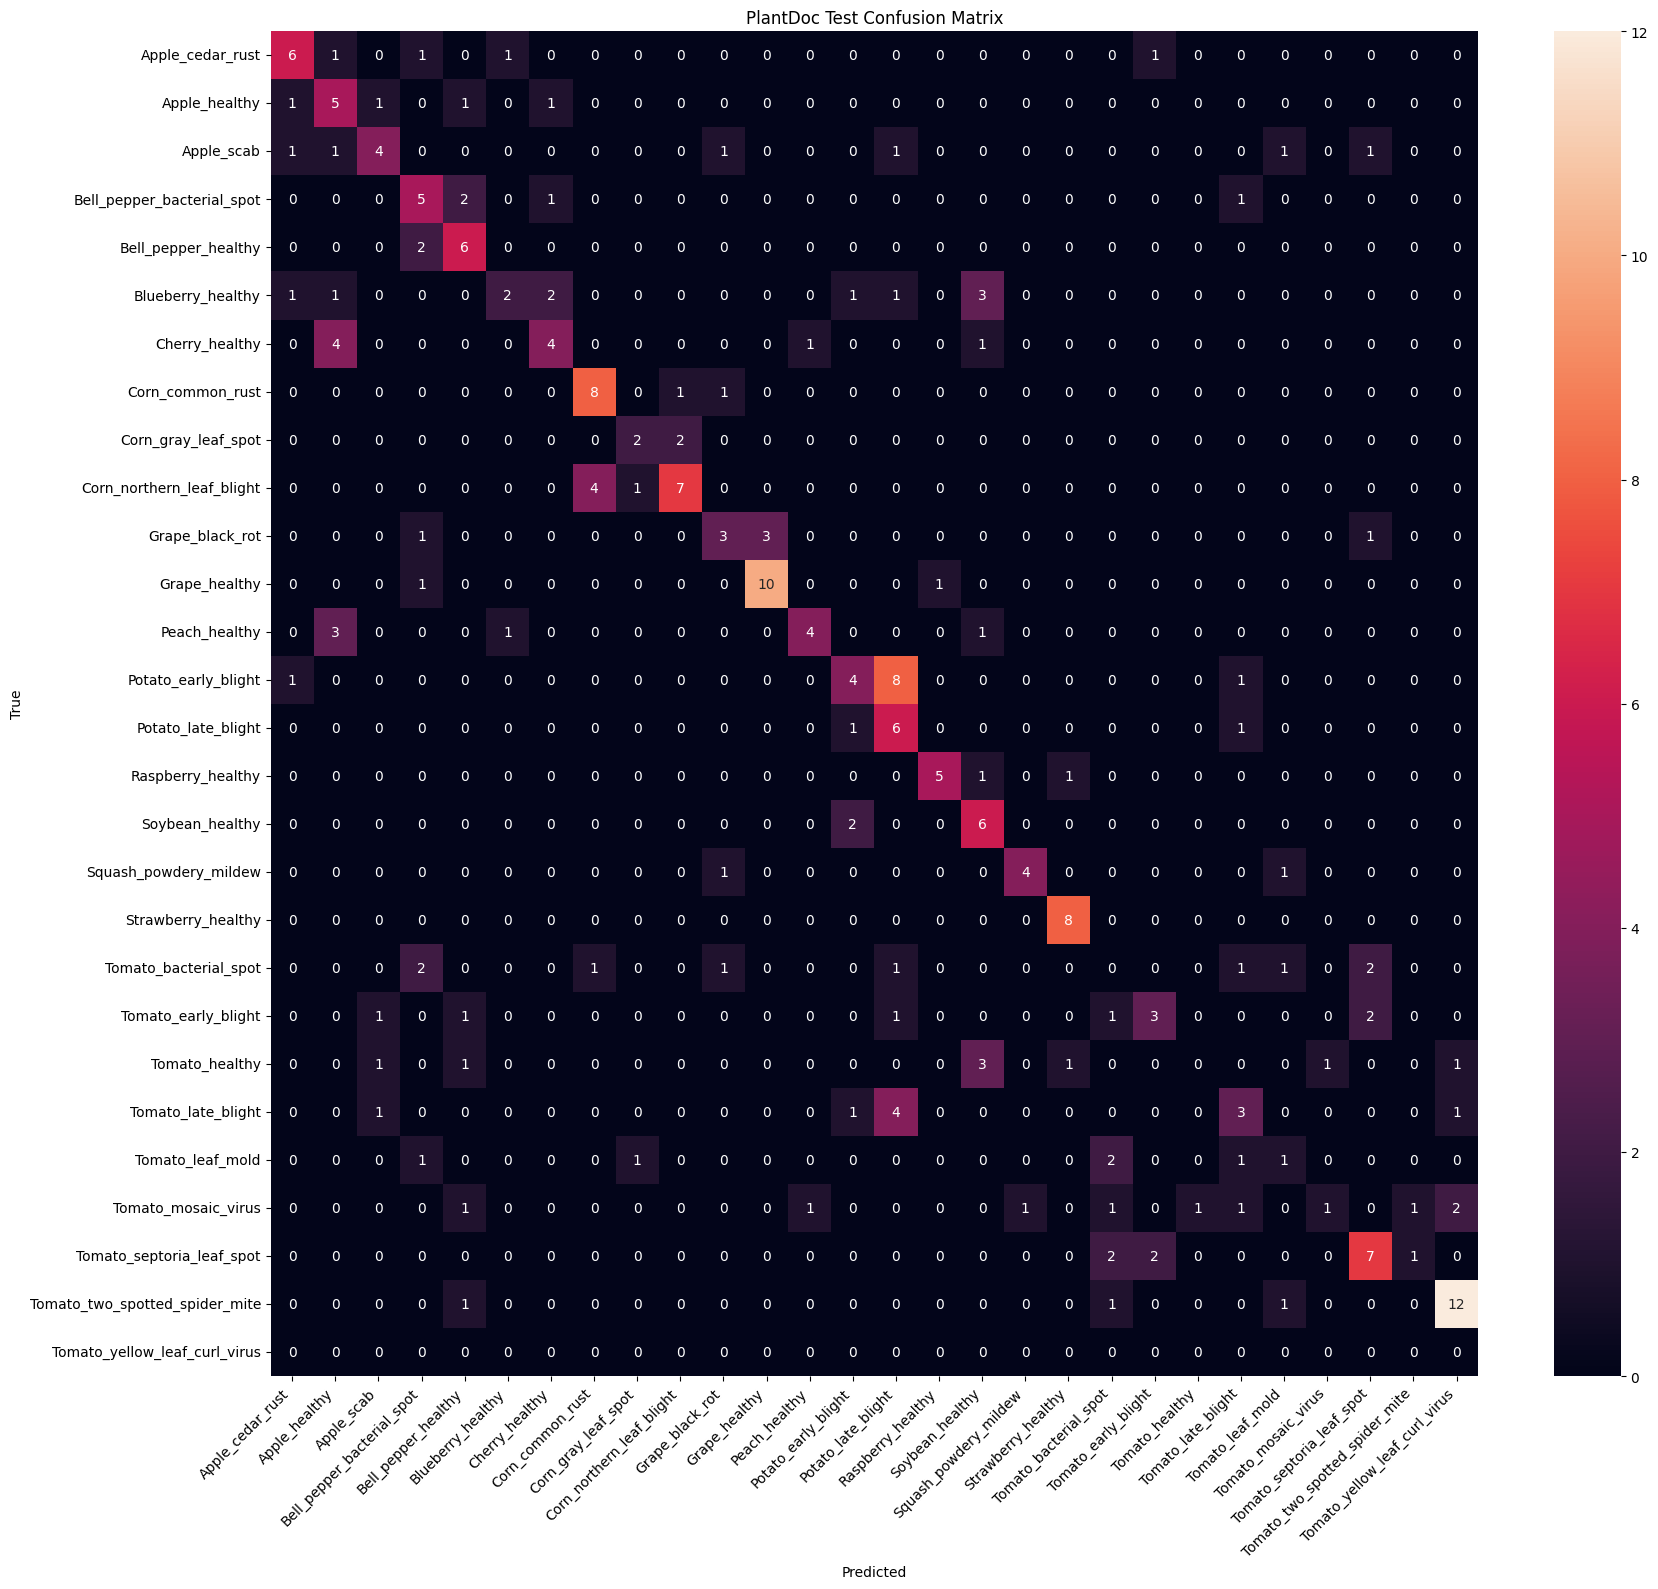

Confusion matrix saved: /content/drive/MyDrive/MY_WORK/PlantDisease_Models/plantdoc_confusion_matrix.png


In [37]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("PlantDoc Test Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(
    OUTPUT_DIR,
    "plantdoc_confusion_matrix.png"
)

plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Confusion matrix saved:", cm_path)

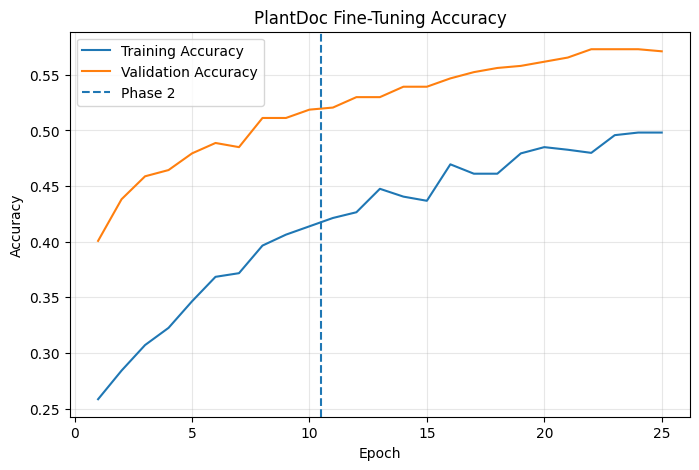

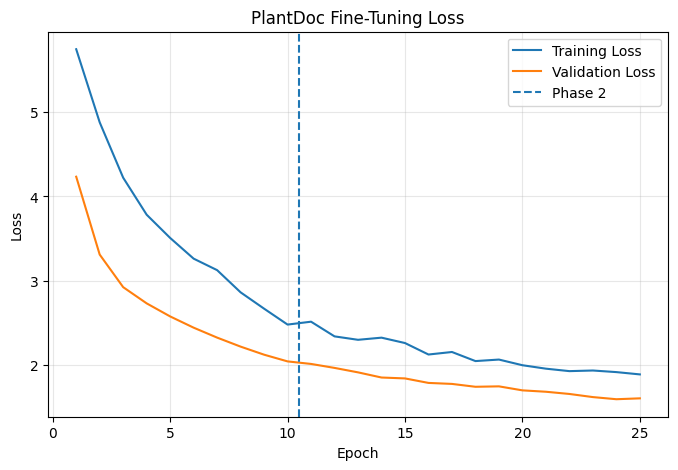

In [38]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

epochs = range(1, len(acc) + 1)
phase2_start = len(history1.history["accuracy"]) + 0.5

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.axvline(phase2_start, linestyle="--", label="Phase 2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PlantDoc Fine-Tuning Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.axvline(phase2_start, linestyle="--", label="Phase 2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PlantDoc Fine-Tuning Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()